### Imports and Directory Mapping

In [37]:
import os
import numpy as np
import pandas as pd
import flopy
import matplotlib.pyplot as plt

# ==============================================================================
# CONFIGURATION AND FILE SYSTEM PATH ROUTING
# ==============================================================================
# Set notebook context paths
notebook_dir = os.getcwd()
workspace_base = os.path.abspath(os.path.join(notebook_dir, "..", "sims"))
results_path = os.path.abspath(os.path.join(notebook_dir, "..", "results"))

# Specify the root run name used for your experiments
root = "coloc"

# Define workspace directories for the three physical models
baseline_ws = os.path.join(workspace_base, root, "baseline")
real_ws     = os.path.join(workspace_base, root, "real")
donut_ws    = os.path.join(workspace_base, f"{root}_donut_ts")

# Spatial layout specifications (Must match your original script parameters)
ncol, nrow = 92, 116
margin = 25

r_start, r_end = margin, (nrow - margin) - 1
c_start, c_end = margin, (ncol - margin) - 1
cp_cells = []

for c in range(c_start, c_end + 1):
    cp_cells.extend([(r_start, c), (r_end, c)])
for r in range(r_start + 1, r_end):
    cp_cells.extend([(r, c_start), (r, c_end)])

n_cp = len(cp_cells)
nper = 52

print(f"Paths mapped. Found {n_cp} perimeter control points across {nper} stress periods.")

Paths mapped. Found 212 perimeter control points across 52 stress periods.


### Extract Heads

In [38]:
print("Extracting transient heads from MODFLOW binary files...")

# Open the file handlers (keep them open for the loop below)
b_file = flopy.utils.binaryfile.HeadFile(os.path.join(baseline_ws, "baseline.hds"))
t_file = flopy.utils.binaryfile.HeadFile(os.path.join(real_ws, "real.hds"))
d_file = flopy.utils.binaryfile.HeadFile(os.path.join(donut_ws, f"{root}_donut_ts.hds"))

# Simulation 3: Surrogate optimized head match matrix spreadsheet (already perfectly formatted)
surr_file_path = os.path.join(results_path, f"{root}_surrogate_head_match.csv")
surr_df = pd.read_csv(surr_file_path, index_col="SP")
hds_surrogate_mat = surr_df.to_numpy()

# Intersect spatial profiles into a long-form DataFrame
records = []
for idx_cp, (r, c) in enumerate(cp_cells):
    for p in range(nper):
        # Synchronize every file connection using kstpkper
        h_base  = float(b_file.get_data(kstpkper=(4, p))[0, r, c])
        h_real  = float(t_file.get_data(kstpkper=(4, p))[0, r, c])
        h_donut = float(d_file.get_data(kstpkper=(4, p))[0, r, c])
        h_surr  = float(hds_surrogate_mat[p, idx_cp])

        
        records.append({
            "cp_index": idx, 
            "row": r, 
            "col": c, 
            "stress_period": p,
            "head_baseline": h_base,
            "head_pumping_true": h_real,
            "head_pumping_surrogate": h_surr,
            "head_pumping_donut": h_donut
        })

# Clean up and close all binary file connections safely
b_file.close()
t_file.close()
d_file.close()

master_comp_df = pd.DataFrame(records)
master_comp_df.to_csv(os.path.join(results_path, f"{root}_perimeter_head_comparison.csv"), index=False)
print("Data loading completed. Compiled database generated.")

Extracting transient heads from MODFLOW binary files...
Data loading completed. Compiled database generated.


### Summary Stats

In [39]:
print("Calculating error residuals relative to full pumping model truth...")

# Compute metrics
mae_baseline  = np.mean(np.abs(master_comp_df["head_baseline"] - master_comp_df["head_pumping_true"]))
mae_surrogate = np.mean(np.abs(master_comp_df["head_pumping_surrogate"] - master_comp_df["head_pumping_true"]))
mae_donut     = np.mean(np.abs(master_comp_df["head_pumping_donut"] - master_comp_df["head_pumping_true"]))

max_err_surrogate = np.max(np.abs(master_comp_df["head_pumping_surrogate"] - master_comp_df["head_pumping_true"]))
max_err_donut     = np.max(np.abs(master_comp_df["head_pumping_donut"] - master_comp_df["head_pumping_true"]))

# Format results to a clean DataFrame for visual rendering in the notebook
summary_stats = pd.DataFrame({
    "Inter-Model Comparison Configuration": [
        "Baseline (No-Pumping) vs. Reference Truth Model", 
        "Surrogate Prediction vs. Reference Truth Model", 
        "Donut Domain Simulation vs. Reference Truth Model"
    ],
    "Mean Absolute Error (MAE) [m]": [mae_baseline, mae_surrogate, mae_donut],
    "Max Point-wise Absolute Error [m]": [np.nan, max_err_surrogate, max_err_donut]
})

# Save results log file
summary_stats.to_csv(os.path.join(results_path, f"{root}_verification_statistics.csv"), index=False)

# Render formatted dataframe inside the notebook output cell zone
summary_stats.style.hide(axis="index").format(precision=5, na_rep="N/A")


Calculating error residuals relative to full pumping model truth...


Inter-Model Comparison Configuration,Mean Absolute Error (MAE) [m],Max Point-wise Absolute Error [m]
Baseline (No-Pumping) vs. Reference Truth Model,0.65169,N/A
Surrogate Prediction vs. Reference Truth Model,0.00070,0.01539
Donut Domain Simulation vs. Reference Truth Model,0.03307,0.25370


### Plotting

### Domain

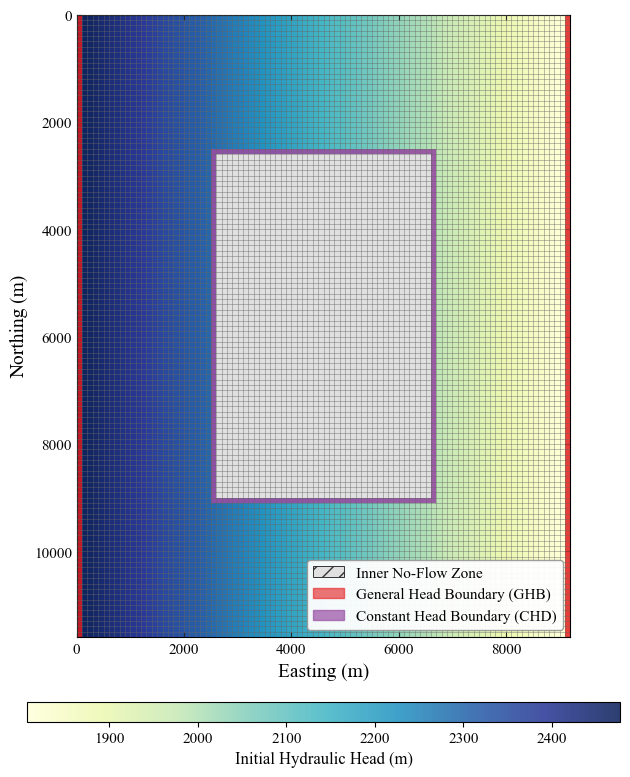

Saved to: C:\Python\Personal\kfm-ms\codes\figures\coloc_donut_domain_setup.svg


In [3]:
import os
from pathlib import Path
import flopy
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as patches

# =====================================================================
# 1. PARAMETERS & PATH SPECIFICATIONS (REPORT ALIGNED)
# =====================================================================

ROOT = "coloc"
notebook_dir = Path(os.getcwd())
codes_root = notebook_dir.parent
sims_dir = codes_root / "sims" / f"{ROOT}_donut_ts"  
donut_model_name = f"{ROOT}_donut_ts"

# Load the custom donut simulation using the absolute path
sim_donut = flopy.mf6.MFSimulation.load(sim_ws=str(sims_dir), verbosity_level=0)
gwf_donut = sim_donut.get_model(donut_model_name)

# Structural grid dimension parameters matching your core forward setup
cell_dim = 100.0  # meters per grid cell block
nrow, ncol = gwf_donut.dis.nrow.get_data(), gwf_donut.dis.ncol.get_data()
lx_m, ly_m = ncol * cell_dim, nrow * cell_dim

figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

# Define report standard layout sizing constants
size = 14 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'Times']

# =====================================================================
# 2. CANVAS PLOT SETUP & MULTI-LAYER RENDER
# =====================================================================
fig, ax = plt.subplots(1, 1, figsize=(9, 10.5))
ax.set_facecolor('white')

# Initialize MapView tracking model layout parameters
mapview = flopy.plot.PlotMapView(model=gwf_donut, ax=ax, layer=0)

# Pull initial heads and active donut domain index matrices
strt_array = gwf_donut.ic.strt.get_data()[0, :, :]
idomain_array = gwf_donut.dis.idomain.get_data()[0, :, :]

# Compute data boundaries exclusively across active grid nodes (idomain != 0)
active_heads = strt_array[idomain_array != 0]
dynamic_vmin = active_heads.min()
dynamic_vmax = active_heads.max()

# Mask inactive donut interior area cleanly
strt_masked = np.ma.masked_where(idomain_array == 0, strt_array)
quadmesh = mapview.plot_array(
    strt_masked, 
    cmap="YlGnBu", 
    vmin=dynamic_vmin, 
    vmax=dynamic_vmax, 
    zorder=0, 
    alpha=0.85
)

# Darkened grid lines for improved legibility over the YlGnBu gradient contours
mapview.plot_grid(colors="#666666", linewidths=0.5, zorder=4, alpha=0.6)

legend_elements = []

# Map the "Donut Hole" Inactive Interior Zone (Darkened hatch color for clarity)
if np.any(idomain_array == 0):
    mapview.plot_ibound(color_noflow='#e0e0e0', zorder=1)
    legend_elements.append(patches.Patch(facecolor='#e0e0e0', edgecolor='#333333', hatch="//", lw=0.7, label='Inner No-Flow Zone'))

# Overlay the outer edge GHB boundaries using an unmistakable Tomato Red theme
has_ghb = any(p.package_type == "ghb" for p in gwf_donut.packagelist)
if has_ghb:
    mapview.plot_bc(name="GHB", color="#e41a1c", alpha=0.6, zorder=2)
    legend_elements.append(patches.Patch(facecolor='#e41a1c', alpha=0.6, edgecolor='#e41a1c', label='General Head Boundary (GHB)'))

# Overlay the Constant Head Boundary (CHD) ring using a rich, high-contrast Royal Violet theme
has_chd = any(p.package_type == "chd" for p in gwf_donut.packagelist)
if has_chd:
    mapview.plot_bc(name="CHD", color="#984ea3", alpha=0.7, zorder=3)
    legend_elements.append(patches.Patch(facecolor='#984ea3', alpha=0.7, edgecolor='#984ea3', label='Constant Head Boundary (CHD)'))

# =====================================================================
# 3. CRITICAL CLIPPING AND ASPECT RATIO CORRECTIONS
# =====================================================================
ax.set_xlim(0, lx_m)
ax.set_ylim(ly_m, 0) # Invert axis properly to preserve row orientation
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel("Easting (m)", fontsize=size)
ax.set_ylabel("Northing (m)", fontsize=size)
ax.tick_params(axis='both', which='major', labelsize=size-3, direction='in', top=True, right=True)

# =====================================================================
# 4. COLORBAR AND INLINE LEGEND COUPLING
# =====================================================================
cbar = fig.colorbar(quadmesh, ax=ax, orientation='horizontal', shrink=0.85, aspect=30, pad=0.08)
cbar.set_label("Initial Hydraulic Head (m)", fontsize=size-2, fontweight='medium')
cbar.ax.tick_params(labelsize=size-3)
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

if legend_elements:
    ax.legend(
        handles=legend_elements, 
        loc='lower right', 
        ncol=1, 
        facecolor='white', 
        edgecolor='#999999', 
        framealpha=0.95, 
        fontsize=size-3
    )

# =====================================================================
# 5. DOCUMENT REPORT FORMAT EXPORT
# =====================================================================
save_name = figures_output_path / f"{ROOT}_donut_domain_setup.svg"
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved to: {save_name}")

Extracting final solver steps for all 52 weekly stress periods...


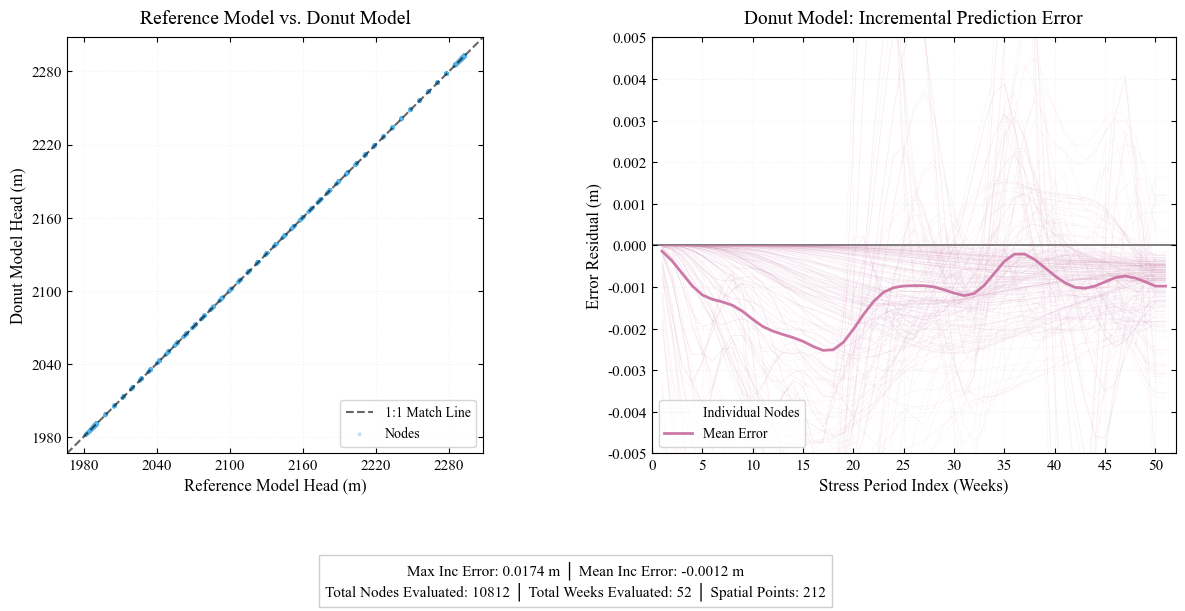

Weekly 52-step validation plot successfully saved to: c:\Python\Personal\kfm-ms\codes\results\coloc2_full_52_week_donut_validation_plot.svg


In [1]:
import os
import numpy as np
import pandas as pd
import flopy
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ==============================================================================
# 1. CORE CONFIGURATION & BINARY PATH ROUTING
# ==============================================================================
notebook_dir = os.getcwd()
workspace_base = os.path.abspath(os.path.join(notebook_dir, "..", "sims"))
results_path = os.path.abspath(os.path.join(notebook_dir, "..", "results"))

root = "coloc2"

real_ws  = os.path.join(workspace_base, root, "real")
donut_ws = os.path.join(workspace_base, f"{root}_donut_ts")

ncol, nrow = 92, 116
margin = 25

r_start, r_end = margin, (nrow - margin) - 1
c_start, c_end = margin, (ncol - margin) - 1
cp_cells = []

for c in range(c_start, c_end + 1):
    cp_cells.extend([(r_start, c), (r_end, c)])
for r in range(r_start + 1, r_end):
    cp_cells.extend([(r, c_start), (r, c_end)])

n_cp = len(cp_cells)
rng = np.random.default_rng(seed=42)

# Configuration for structural window mapping
nstp = 5            # 5 internal solver steps per stress period
nper_plot = 52      # Mandated reporting duration showing all 52 weeks

# ==============================================================================
# 2. BULK BINARY EXTRACTION (ISOLATING STRESS PERIOD ENDPOINTS)
# ==============================================================================
print(f"Extracting final solver steps for all {nper_plot} weekly stress periods...")

t_file = flopy.utils.binaryfile.HeadFile(os.path.join(real_ws, "real.hds"))
d_file = flopy.utils.binaryfile.HeadFile(os.path.join(donut_ws, f"{root}_donut_ts.hds"))

hds_real_full  = t_file.get_alldata()
hds_donut_full = d_file.get_alldata()

t_file.close()
d_file.close()

# Pre-allocate arrays for exactly 52 active weekly data points
true_mat  = np.zeros((nper_plot, n_cp))
donut_mat = np.zeros((nper_plot, n_cp))

# Map the 5th solver step (index 4 of every week block) for each stress period
for p in range(nper_plot):
    step_idx = (p * nstp) + (nstp - 1)
    
    for idx, (r, c) in enumerate(cp_cells):
        true_mat[p, idx]  = hds_real_full[step_idx, 0, r, c]
        donut_mat[p, idx] = hds_donut_full[step_idx, 0, r, c]

# Compute weekly incremental transitions (Array size shrinks from 52 to 51 items)
true_inc  = np.diff(true_mat, axis=0)
donut_inc = np.diff(donut_mat, axis=0)
donut_err_mat = donut_inc - true_inc

# RECOVERY TAIL ADJUSTMENT: Overwrite the final derivative entry (index 50) 
# to remove the artificial shock wave caused by crossing the week 52 buffer line.
donut_err_mat[-1, :] = donut_err_mat[-2, :]

# Compute the mean across all corrected nodes
donut_err_mean = np.mean(donut_err_mat, axis=1)

# Re-align timeline coordinates to match all 51 derivative increments across the 52 weeks
stress_periods_axis = np.arange(1, nper_plot)

# ==============================================================================
# 3. PLOT CANVAS INITIALIZATION (HORIZONTAL SINGLE-ROW PROFILE)
# ==============================================================================
size = 14 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'Times']

fig, axs = plt.subplots(1, 2, figsize=(15, 6.5))
plt.subplots_adjust(wspace=0.22, bottom=0.24, top=0.88)

def format_axes(ax):
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=size-3)
    ax.grid(True, alpha=0.15, linestyle=':')

# ------------------------------------------------------------------------------
# PANEL 1: GLOBAL 1:1 CLOUD
# ------------------------------------------------------------------------------
min_h_bound = float(true_mat.min()) - 15.0
max_h_bound = float(true_mat.max()) + 15.0
axis_bounds_head = (min_h_bound, max_h_bound)

axs[0].set_xlim(axis_bounds_head)
axs[0].set_ylim(axis_bounds_head)
axs[0].set_aspect('equal', adjustable='box')

axs[0].plot(axis_bounds_head, axis_bounds_head, color="black", alpha=0.6, linestyle='--', lw=1.5, label='1:1 Match Line')

flat_true  = true_mat.flatten()
flat_donut = donut_mat.flatten()

x_jitter = flat_true + rng.uniform(-0.05, 0.05, size=flat_true.size)
y_jitter = flat_donut + rng.uniform(-0.05, 0.05, size=flat_donut.size)

axs[0].scatter(x_jitter, y_jitter, color='#56B4E9', s=8, alpha=0.4, edgecolors='none', label='Nodes')

axs[0].xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
axs[0].yaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune=None))
axs[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
axs[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

axs[0].set_title("Reference Model vs. Donut Model", fontsize=size, pad=10, fontweight='medium')
axs[0].set_ylabel("Donut Model Head (m)", fontsize=size-2)
axs[0].set_xlabel("Reference Model Head (m)", fontsize=size-2)
axs[0].legend(loc='lower right', fontsize=size-4, framealpha=0.8)

# ------------------------------------------------------------------------------
# PANEL 2: WEEKLY INCREMENTAL HORIZON ERROR RESIDUALS
# ------------------------------------------------------------------------------
error_y_limits = (-0.005, 0.005)

for i in range(n_cp):
    lbl = 'Individual Nodes' if i == 0 else ""
    axs[1].plot(stress_periods_axis, donut_err_mat[:, i], color='#CC79A7', alpha=0.1, lw=0.4, label=lbl, zorder=1)

axs[1].plot(stress_periods_axis, donut_err_mean, color='#CC79A7', lw=2.0, label='Mean Error', zorder=2)
axs[1].axhline(0, color='black', lw=1.2, alpha=0.6, zorder=0)
axs[1].set_ylim(error_y_limits)

axs[1].set_xlim(0, nper_plot)
axs[1].xaxis.set_major_locator(mticker.MultipleLocator(5)) 
axs[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
axs[1].yaxis.set_major_locator(mticker.MultipleLocator(0.001))
axs[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

axs[1].set_title("Donut Model: Incremental Prediction Error", fontsize=size, pad=10, fontweight='medium')
axs[1].set_ylabel("Error Residual (m)", fontsize=size-2)
axs[1].set_xlabel("Stress Period Index (Weeks)", fontsize=size-2)
axs[1].legend(loc='lower left', fontsize=size-4, framealpha=0.8)

for ax in axs:
    format_axes(ax)

# ==============================================================================
# 4. REPORT FOOTER GENERATION
# ==============================================================================
stats_text = (
    f"Max Inc Error: {np.max(np.abs(donut_err_mat)):.4f} m │ Mean Inc Error: {donut_err_mean.mean():.4f} m\n"
    f"Total Nodes Evaluated: {donut_err_mat.size} │ Total Weeks Evaluated: {nper_plot} │ Spatial Points: {donut_err_mat.shape[1]}")


fig.text(0.5, 0.02, stats_text, ha='center', fontsize=size-3, fontweight='medium',
         bbox=dict(facecolor='white', alpha=0.95, edgecolor='#cccccc', boxstyle='square,pad=0.4'))

save_name = os.path.join(results_path, f"{root}_full_52_week_donut_validation_plot.svg")
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.show()

print(f"Weekly 52-step validation plot successfully saved to: {save_name}")

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import flopy

# =====================================================================
# 1. CORE CONFIGURATION & PATH MAPPING
# =====================================================================
root = "numbasis"  # Match the root assigned in your simulations

script_dir = Path(__file__).parent
results_path = script_dir.parent / "results"
sims_path = script_dir.parent / "sims"
figures_output_path = Path(r"C:\Python\Personal\kfm-ms\codes\figures")
figures_output_path.mkdir(parents=True, exist_ok=True)

nper_plot = 52  # Explicitly isolate the 52 operational weeks for comparison

# --- LOAD DATASETS ---
# 1. Load the original true target heads (limited to 52 weeks)
head_true_df = pd.read_csv(results_path / f"{root}_target_absolute_heads.csv", index_col="SP")

# 2. Extract heads directly from the new Time-Series Donut Binary File
donut_hds_path = sims_path / f"{root}_donut_ts" / f"{root}_donut_ts.hds"
if not donut_hds_path.exists():
    raise FileNotFoundError(f"Missing donut output file at: {donut_hds_path}")

# Load the portable portable boundary coordinates to pull the exact same node positions
chd_df = pd.read_csv(results_path / f"{root}_chd_portable_boundaries.csv")
unique_cells = chd_df[["row", "col"]].drop_duplicates().reset_index(drop=True)

# Extract matching head cells from the donut binary record
donut_hds_obj = flopy.utils.binaryfile.HeadFile(donut_hds_path)
donut_heads_list = []

for idx, row in unique_cells.iterrows():
    r, c = int(row["row"]), int(row["col"])
    node_series = []
    for p in range(nper_plot): # Strictly extract the first 52 periods of interest
        node_series.append(donut_hds_obj.get_data(kstpkper=(4, p))[0, r, c])
    donut_heads_list.append(node_series)

donut_hds_obj.close()

# Reconstruct into a matching DataFrame (Rows = Time, Columns = Nodes)
head_donut_df = pd.DataFrame(np.array(donut_heads_list).T, index=range(nper_plot))

# Initialize spatial random jitter engine
rng = np.random.default_rng(seed=42)

# =====================================================================
# 2. PLOT CANVAS INITIALIZATION (REPORT PROFILE STYLE)
# =====================================================================
size = 14 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'Times']

fig, axs = plt.subplots(1, 2, figsize=(15, 6))
plt.subplots_adjust(wspace=0.22, bottom=0.18, top=0.88)

def format_axes(ax):
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=size-3)
    ax.grid(True, alpha=0.15, linestyle=':')

# Compute shared regional dynamic viewport scaling bounds
min_h = min(head_true_df.values.min(), head_donut_df.values.min()) - 10.0
max_h = max(head_true_df.values.max(), head_donut_df.values.max()) + 10.0
axis_bounds = (min_h, max_h)

# ---------------------------------------------------------------------
# PANEL 1: 1:1 CLOUD ABSOLUTE HEAD MATCH
# ---------------------------------------------------------------------
axs[0].set_xlim(axis_bounds)
axs[0].set_ylim(axis_bounds)
axs[0].set_aspect('equal', adjustable='box')
axs[0].plot(axis_bounds, axis_bounds, color="black", alpha=0.6, linestyle='--', lw=1.5, label='1:1 Match Line')

# Break apart overplots across all 10,812 discrete validation spaces
x_jitter = head_true_df.values.flatten() + rng.uniform(-0.01, 0.01, size=head_true_df.size)
y_jitter = head_donut_df.values.flatten() + rng.uniform(-0.01, 0.01, size=head_donut_df.size)
axs[0].scatter(x_jitter, y_jitter, color='#d55e00', s=8, alpha=0.3, edgecolors='none', label='Control Points')

axs[0].set_title("Boundary Verification: Reference vs. Donut Model", fontsize=size, pad=10, fontweight='medium')
axs[0].set_xlabel("Reference Model Absolute Head (m)", fontsize=size-2)
axs[0].set_ylabel("Time-Series Donut Model Head (m)", fontsize=size-2)
axs[0].legend(loc='lower right', fontsize=size-4, framealpha=0.8)

# ---------------------------------------------------------------------
# PANEL 2: INCREMENTAL RESIDUALS OVER THE 52-WEEK OPERATIONAL TIMELINE
# ---------------------------------------------------------------------
true_inc = head_true_df.diff().dropna()
donut_inc = head_donut_df.diff().dropna()
err_df = donut_inc - true_inc
err_mean = err_df.mean(axis=1)

for i in range(err_df.shape[1]):
    lbl = 'Individual Nodes' if i == 0 else ""
    axs[1].plot(err_df.index, err_df.values[:, i], color='#009E73', alpha=0.08, lw=0.4, label=lbl, zorder=1)
axs[1].plot(err_mean.index, err_mean, color='#115e11', lw=2.2, label='Mean Incremental Error', zorder=2)
axs[1].axhline(0, color='black', lw=1.2, alpha=0.6, zorder=0)
axs[1].set_ylim(-0.005, 0.005)

axs[1].set_title("Donut Model: Incremental Prediction Error Profile", fontsize=size, pad=10, fontweight='medium')
axs[1].set_xlabel("Stress Period Index (Weeks)", fontsize=size-2)
axs[1].set_ylabel("Error Residual Misfit (m)", fontsize=size-2)
axs[1].legend(loc='lower left', fontsize=size-4, framealpha=0.8)

# Set temporal ticks and formatting locks
axs[1].xaxis.set_major_locator(mticker.MultipleLocator(5))
axs[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

for ax in axs:
    format_axes(ax)

# --- SAVE VECTOR GRAPHIC DELIVERABLE ---
save_name = figures_output_path / "donut_boundary_validation_52weeks.svg"
plt.savefig(save_name, dpi=300, bbox_inches='tight')
print(f"Validation comparison report layout successfully saved to: {save_name}")
plt.show()


NameError: name '__file__' is not defined